In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate
from model_pipelines import ModelConstructor

In [2]:
plt.rcParams['figure.dpi'] = 300

In [3]:
## Loop through each model, pipeline category and pipeline
pipeline_categories = ['xgb', 'lgbm', 'stack']
models = ['A', 'B', 'C']

results = {}
for mclass in ['A', 'B', 'C']:
    result = {}
    for pipeline_category in pipeline_categories:
        model = ModelConstructor(mclass)
        pipelines = model.fetch_pipelines(pipeline_category)

        X_train, X_test, y_train, y_test = model.fetch_splits()

        cvs = {}
        for key, pipeline in pipelines.items():
            cv = cross_validate(
                pipeline, X_train, y_train,
                cv=5, scoring='f1_macro', return_estimator=True,
            )

            tp = np.where(cv['test_score']==cv['test_score'].max())[0][0]
            held_out_score = cv['estimator'][tp].score(X_test, y_test, scoring = 'f1_macro')

            cvs[key] = cv
            cvs[key]['score_mean'] = cv['test_score'].mean() 
            cvs[key]['score_std'] = cv['test_score'].std()
            cvs[key]['best_fold'] = tp
            cvs[key]['held_out_score'] = held_out_score 
        result[pipeline_category] = cvs
    results[mclass] = result

In [4]:
# Extract results into flat lists
pipeline_categories = ['xgb', 'lgbm', 'stack']
pipeline_keys = ['model_only', 'pca_model', 'pls_model']
model_classes = ['A', 'B', 'C']
arch_labels = [f'{p}_{k}' for p in pipeline_categories for k in ['only', 'pca', 'pls']]

# Build flat data arrays
rows = []
for mclass in model_classes:
    for pcat in pipeline_categories:
        for pkey in pipeline_keys:
            r = results[mclass][pcat][pkey]
            rows.append({
                'Model': mclass,
                'Architecture': f"{pcat}_{pkey.replace('model_only','only').replace('_model','')}",
                'CV_mean': r['score_mean'],
                'CV_std': r['score_std'],
                'Test_score': r['held_out_score']
            })

results_df = pd.DataFrame(rows)

In [5]:
pd.pivot_table(
    results_df, 
    values=list(results_df.columns[-3:]), 
    index=['Architecture'],
    columns=['Model']
)

CV_mean                        CV_std                      \
Model                A         B         C         A         B         C   
Architecture                                                               
lgbm_only     0.567323  0.643951  0.721550  0.017677  0.010898  0.006817   
lgbm_pca      0.538244  0.620296  0.678651  0.012012  0.013464  0.020726   
lgbm_pls      0.504881  0.648757  0.670767  0.005794  0.005642  0.022675   
stack_only    0.570932  0.648867  0.719365  0.015133  0.008651  0.004241   
stack_pca     0.537507  0.625124  0.676851  0.011711  0.015262  0.023182   
stack_pls     0.516366  0.645564  0.668858  0.003590  0.008713  0.018663   
xgb_only      0.562833  0.652350  0.715950  0.016605  0.010990  0.010299   
xgb_pca       0.541731  0.627799  0.674976  0.025336  0.012411  0.023414   
xgb_pls       0.510584  0.642957  0.669489  0.004290  0.007296  0.014445   

             Test_score                      
Model                 A         B         C  
Architecture                                 
lgbm_only      0.646328  0.733804  0.802120  
lgbm_pca       0.616949  0.698469  0.784452  
lgbm_pls       0.544633  0.746761  0.782097  
stack_only     0.627119  0.734982  0.799764  
stack_pca      0.607910  0.711425  0.786808  
stack_pls      0.520904  0.749117  0.784452  
xgb_only       0.636158  0.733804  0.791519  
xgb_pca        0.595480  0.711425  0.789164  
xgb_pls        0.524294  0.736160  0.775029

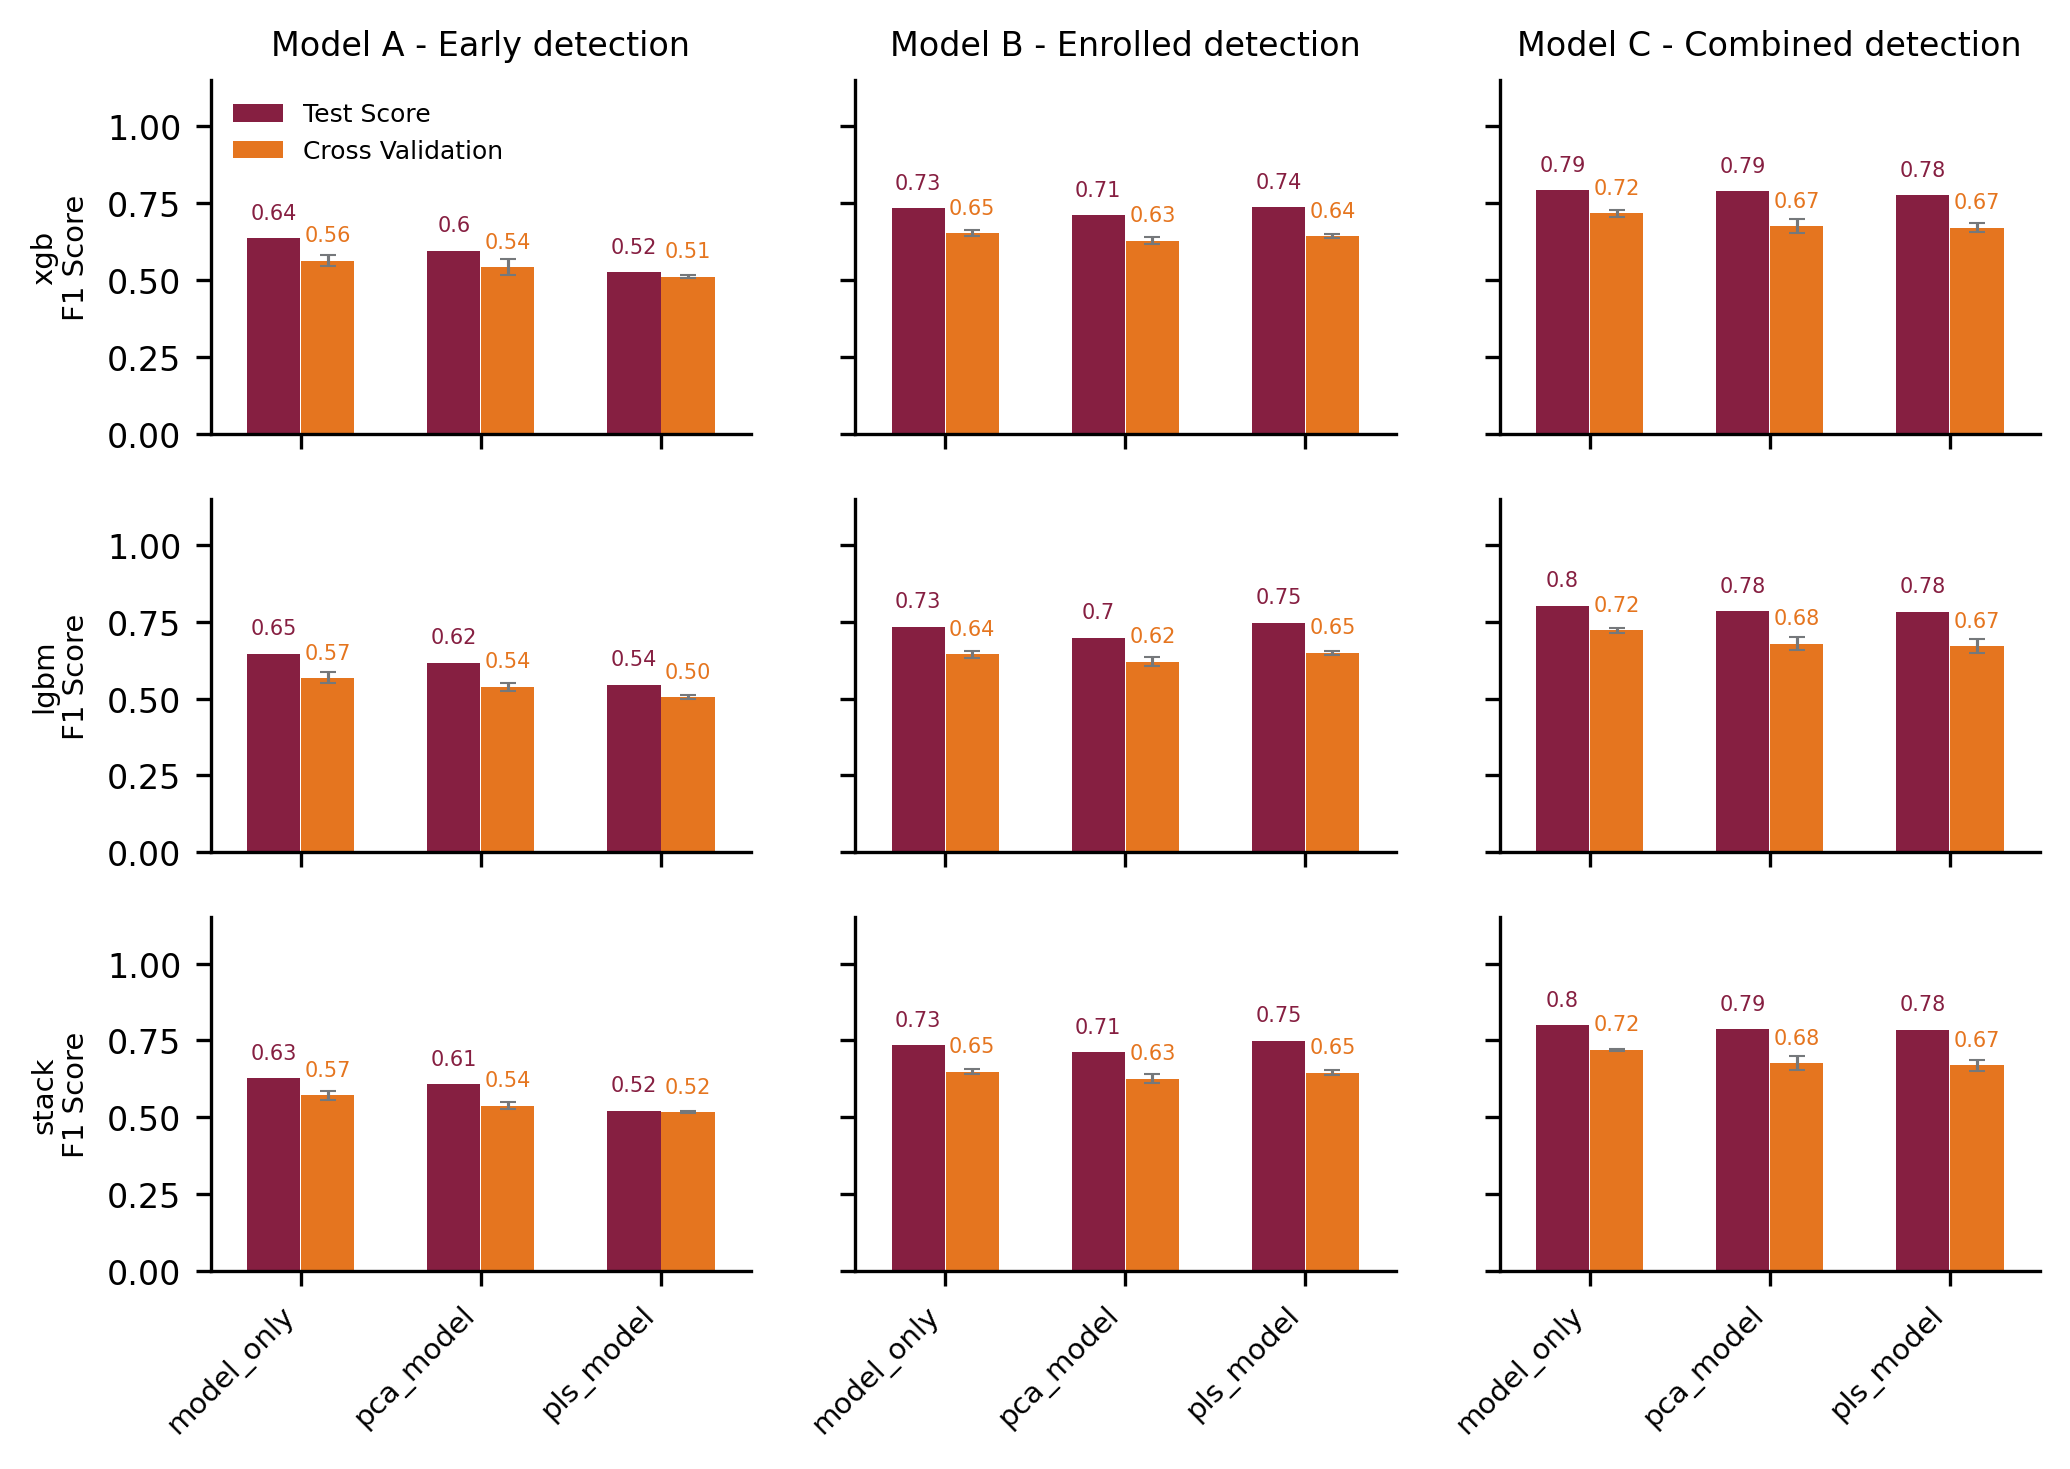

In [ ]:
# Summary plot — 3 rows (one per pipeline category) x 3 cols (one per model)
fig, ax = plt.subplots(3, 3, figsize=(7, 5), sharey=True)
x_positions = [1.2, 3.2, 5.2]
x_cv = [1.8, 3.8, 5.8]
x_ticks = [1.5, 3.5, 5.5]
tick_labels = ['model_only', 'pca_model', 'pls_model']
model_labels = ['Early detection', 'Enrolled detection', 'Combined detection']

for row, pcat in enumerate(pipeline_categories):
    for col, mclass in enumerate(model_classes):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize=8)

        subset = results_df[
            (results_df['Model'] == mclass) & (results_df['Architecture'].str.startswith(pcat))
        ]

        test_scores = subset['Test_score'].values
        cv_means = subset['CV_mean'].values
        cv_stds = subset['CV_std'].values

        bars_test = ax[row, col].bar(x_positions, test_scores, width=0.59, color='#861F41', label='Test Score')
        bars_cv = ax[row, col].bar(x_cv, cv_means, width=0.59, color='#E5751F', label='Cross Validation')
        ax[row, col].errorbar(
            x_cv, 
            cv_means, 
            cv_stds, 
            fmt='o', 
            markersize=0,
            color='#75787b', 
            elinewidth=0.75, 
            capsize=2, 
            capthick=0.5
        )

        # Annotate test score bars
        for bar, val in zip(bars_test, test_scores):
            ax[row, col].text(
                bar.get_x() + bar.get_width() / 2, 
                bar.get_height() + 0.05,
                f'{val.round(2)}', 
                ha='center', 
                va='bottom', 
                fontsize=5, 
                color='#861F41'
            )

        # Annotate CV mean bars
        for bar, val in zip(bars_cv, cv_means):
            ax[row, col].text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f'{val:.2f}', 
                ha='center', 
                va='bottom', 
                fontsize=5, 
                color='#E5751F'
            )

        ax[row, col].set_xticks(x_ticks)
        ax[row, col].set_xlim(0.5, 6.5)
        ax[row, col].set_ylim(0, 1.15)

        if row == 2:
            ax[row, col].set_xticklabels(tick_labels, fontsize=7, rotation=45, ha='right')
        else:
            ax[row, col].set_xticklabels([], fontsize=7)

        if col == 0:
            ax[row, col].set_ylabel(f"{pcat}\nF1 Score", fontsize=7)
            if row == 0:
                ax[row, col].legend(fontsize=6, frameon=False, loc='upper left')

        if row == 0:
            ax[row, col].set_title(f"Model {mclass} - {model_labels[col]}", fontsize=8)

plt.tight_layout()